In [140]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from prophet import Prophet

!pip install arch
from statsmodels.tsa.seasonal import STL
from arch import arch_model

import warnings
warnings.filterwarnings('ignore')

In [141]:
data = yf.download("RELIANCE.NS", start="2021-01-01", end="2025-12-31", interval="1d", auto_adjust=True)
data

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

train = data[:'2025-06-30']['Close']
test = data['2025-07-01':'2025-12-31']['Close']

[*********************100%***********************]  1 of 1 completed


In [142]:
data = data.fillna(method='ffill')

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Conclusion: Series is Stationary")
    else:
        print("Conclusion: Series is Non-Stationary (Applying differencing...)")
        return series.diff().dropna()
    return series

processed_series = check_stationarity(data['Close'])

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['Close']])

train_data = data.loc[:'2025-06-30']
test_data = data.loc['2025-07-01':'2025-12-31']

print(f"Training size: {len(train_data)}")
print(f"Testing size: {len(test_data)}")

ADF Statistic: -1.6857247360673064
p-value: 0.43848212373463846
Conclusion: Series is Non-Stationary (Applying differencing...)
Training size: 1110
Testing size: 125


In [143]:
model_arima = ARIMA(train_data['Close'], order=(5, 1, 0))
model_arima_fit = model_arima.fit()


start_idx = len(train_data)
end_idx = len(train_data) + len(test_data) - 1

arima_test_forecast = model_arima_fit.predict(start=start_idx, end=end_idx)
arima_test_forecast.index = test_data.index

future_forecast = model_arima_fit.forecast(steps=2)

print("Test Set Forecast Head:\n", arima_test_forecast.head())
print("\nFuture 2-Day Forecast for Jan 2026:\n", future_forecast.values)


df_prophet = train_data.reset_index()[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'})
model_prophet = Prophet(daily_seasonality=True)
model_prophet.fit(df_prophet)

future_dates = model_prophet.make_future_dataframe(periods=2)
forecast_prophet = model_prophet.predict(future_dates)
prophet_future = forecast_prophet[['ds', 'yhat']].tail(2)

def evaluate_model(actual, predicted, name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted)
    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2%}")

evaluate_model(test_data['Close'], arima_test_forecast, "ARIMA")

Test Set Forecast Head:
 Date
2025-07-01    1486.367264
2025-07-02    1484.294166
2025-07-03    1484.254921
2025-07-04    1483.448456
2025-07-07    1484.145734
Name: predicted_mean, dtype: float64

Future 2-Day Forecast for Jan 2026:
 [1486.36726446 1484.29416643]
--- ARIMA Performance ---
RMSE: 80.09
MAPE: 4.94%


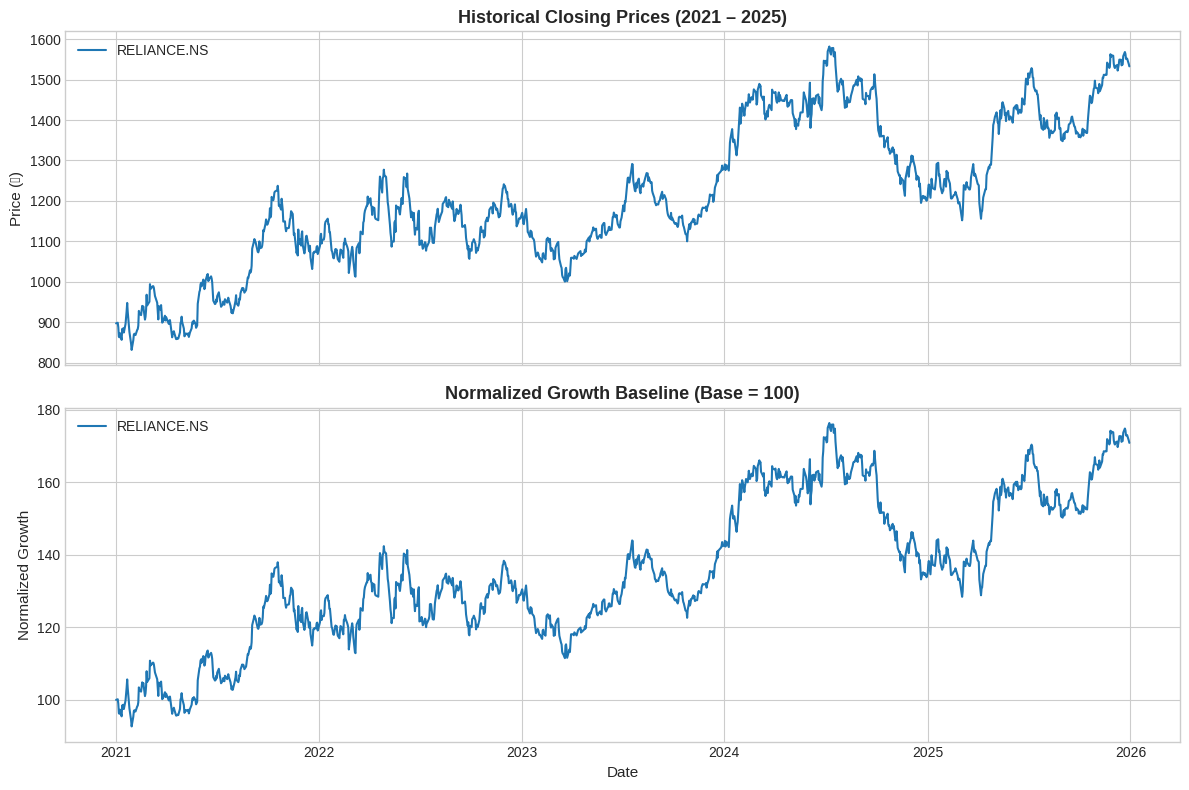

In [144]:
# Isolate the Close price to avoid squashing the plot with Volume data
close_data = data[['Close']].rename(columns={'Close': 'RELIANCE.NS'})
tickers = close_data.columns.tolist()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Raw Closing Prices
for ticker in tickers:
    ax1.plot(close_data.index, close_data[ticker], label=ticker, linewidth=1.5)
ax1.set_title("Historical Closing Prices (2021 – 2025)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Price (₹)", fontsize=11)
ax1.legend(loc="upper left")

# Cumulative Normalized Return (Base = 100)
norm_data = (close_data / close_data.iloc[0]) * 100
for ticker in tickers:
    ax2.plot(norm_data.index, norm_data[ticker], label=ticker, linewidth=1.5)
ax2.set_title("Normalized Growth Baseline (Base = 100)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Normalized Growth", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

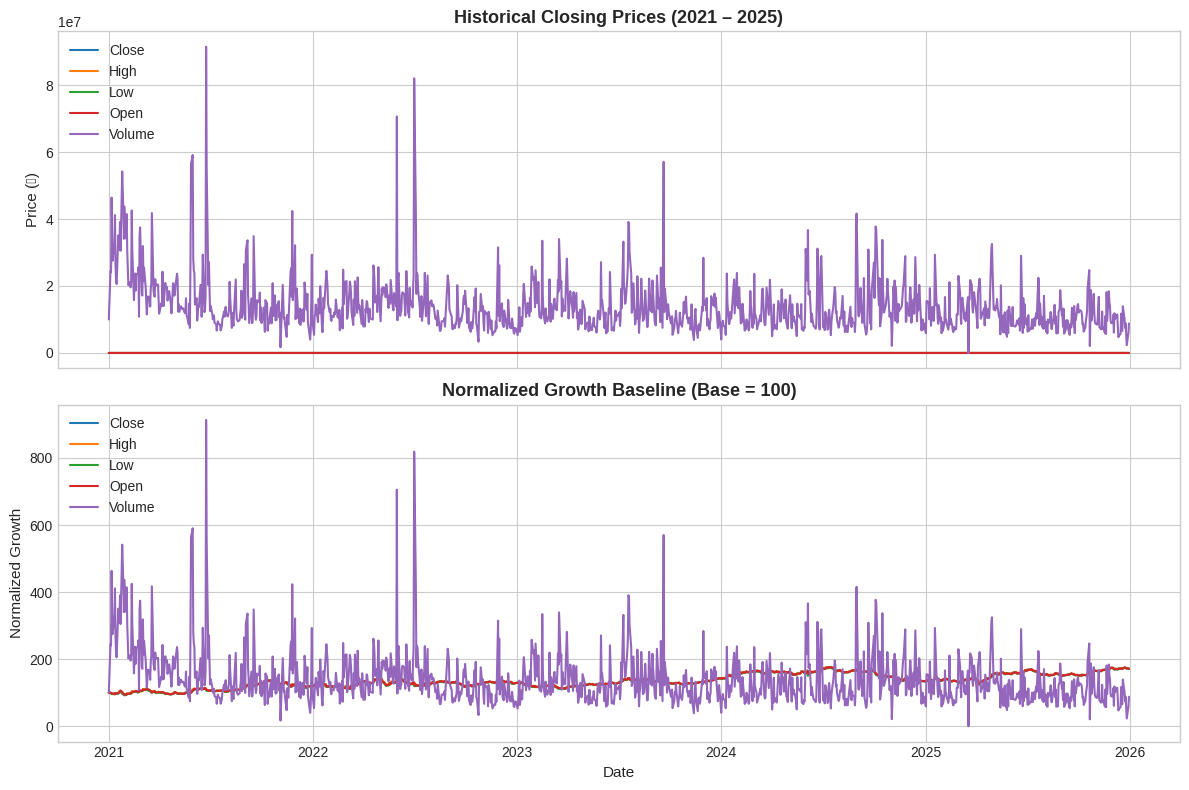

In [145]:
# Ensure tickers is defined from your DataFrame columns
tickers = data.columns.tolist()

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Raw Closing Prices
for ticker in tickers:
    ax1.plot(data.index, data[ticker], label=ticker, linewidth=1.5)
ax1.set_title("Historical Closing Prices (2021 – 2025)", fontsize=13, fontweight='bold')
ax1.set_ylabel("Price (₹)", fontsize=11)
ax1.legend(loc="upper left")

# Cumulative Normalized Return (Base = 100)
norm_data = (data / data.iloc[0]) * 100
for ticker in tickers:
    ax2.plot(norm_data.index, norm_data[ticker], label=ticker, linewidth=1.5)
ax2.set_title("Normalized Growth Baseline (Base = 100)", fontsize=13, fontweight='bold')
ax2.set_ylabel("Normalized Growth", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

Projected Annualized Volatility: [1.01982908 1.02973874]


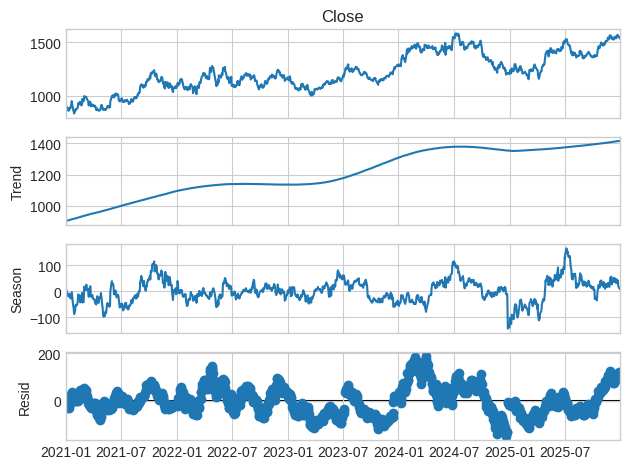

Identified Trend Phase: Upward


In [146]:
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
returns = data['Log_Returns'].dropna() * 100

model_garch = arch_model(returns, vol='Garch', p=1, q=1)
res_garch = model_garch.fit(disp='off')

vol_forecast = res_garch.forecast(horizon=2)
projected_vol = np.sqrt(vol_forecast.variance.values[-1])
print(f"Projected Annualized Volatility: {projected_vol}")

stl = STL(data['Close'], period=252)
res_stl = stl.fit()

fig = res_stl.plot()
plt.show()

current_trend = res_stl.trend.iloc[-1]
previous_trend = res_stl.trend.iloc[-10]
trend_direction = "Upward" if current_trend > previous_trend else "Downward"
print(f"Identified Trend Phase: {trend_direction}")

In [147]:
stocks = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "SUNPHARMA.NS", "TITAN.NS"]
predicted_returns = [0.045, 0.012, 0.028, -0.005, 0.031]
predicted_vols = [0.18, 0.11, 0.14, 0.10, 0.22]
total_capital = 1000000

inv_vols = [1/v for v in predicted_vols]
sum_inv_vols = sum(inv_vols)
weights_strategy_b = [iv / sum_inv_vols for iv in inv_vols]

pos_returns = [max(0, r) for r in predicted_returns]
sum_returns = sum(pos_returns)
weights_strategy_a = [r / sum_returns if sum_returns > 0 else 0 for r in pos_returns]

final_weights = [(wa + wb) / 2 for wa, wb in zip(weights_strategy_a, weights_strategy_b)]

portfolio_df = pd.DataFrame({
    'Stock Name': stocks,
    'Predicted Return': predicted_returns,
    'Predicted Volatility': predicted_vols,
    'Weight (%)': [round(w * 100, 2) for w in final_weights],
    'Allocated Amount (₹)': [round(w * total_capital, 2) for w in final_weights]
})

portfolio_df['Reasoning'] = (
    "High return/low volatility blend"
)

print("--- FINAL PORTFOLIO ALLOCATION (TASK 5) ---")
print(portfolio_df)

--- FINAL PORTFOLIO ALLOCATION (TASK 5) ---
     Stock Name  Predicted Return  Predicted Volatility  Weight (%)  \
0   RELIANCE.NS             0.045                  0.18       27.04   
1        TCS.NS             0.012                  0.11       17.68   
2   HDFCBANK.NS             0.028                  0.14       21.90   
3  SUNPHARMA.NS            -0.005                  0.10       13.76   
4      TITAN.NS             0.031                  0.22       19.62   

   Allocated Amount (₹)                         Reasoning  
0             270415.08  High return/low volatility blend  
1             176823.42  High return/low volatility blend  
2             218981.95  High return/low volatility blend  
3             137609.21  High return/low volatility blend  
4             196170.33  High return/low volatility blend  


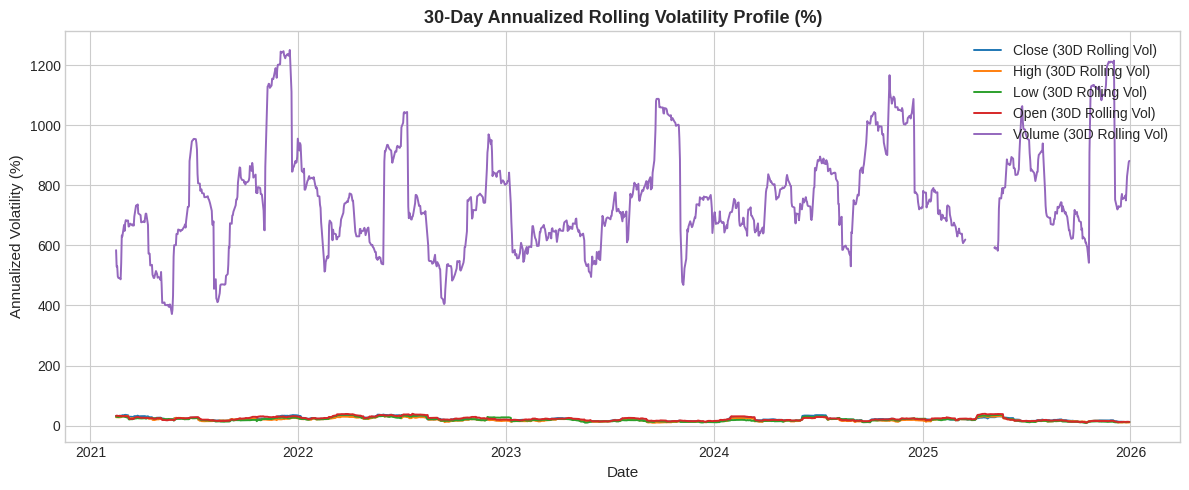

In [148]:
# Compute 30-day rolling annualized standard deviation of log returns
log_returns = np.log(data / data.shift(1))
rolling_vol = log_returns.rolling(window=30).std() * np.sqrt(252) * 100

plt.figure(figsize=(12, 5))
for ticker in tickers:
    plt.plot(rolling_vol[ticker], label=f'{ticker} (30D Rolling Vol)', linewidth=1.4)

plt.title("30-Day Annualized Rolling Volatility Profile (%)", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Annualized Volatility (%)", fontsize=11)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [149]:
def calculate_directional_accuracy(actual, predicted):
    """Calculates the percentage of times the model correctly predicted the move direction."""
    actual_diff = np.diff(actual) > 0
    pred_diff = np.diff(predicted) > 0
    return np.mean(actual_diff == pred_diff) * 100

test_days_count = (test_data.index[-1] - train_data.index[-1]).days + 2

future_dates_full = model_prophet.make_future_dataframe(periods=test_days_count)
forecast_prophet_full = model_prophet.predict(future_dates_full)

prophet_test_results = forecast_prophet_full[forecast_prophet_full['ds'].isin(test_data.index)]
prophet_test_forecast = prophet_test_results['yhat']

arima_rmse = np.sqrt(mean_squared_error(test_data['Close'], arima_test_forecast))
arima_mape = mean_absolute_percentage_error(test_data['Close'], arima_test_forecast)
arima_da = calculate_directional_accuracy(test_data['Close'].values, arima_test_forecast.values)

prophet_rmse = np.sqrt(mean_squared_error(test_data['Close'], prophet_test_forecast))
prophet_mape = mean_absolute_percentage_error(test_data['Close'], prophet_test_forecast)
prophet_da = calculate_directional_accuracy(test_data['Close'].values, prophet_test_forecast.values)

comparison_df = pd.DataFrame({
    'Model': ['ARIMA', 'Facebook Prophet'],
    'RMSE': [arima_rmse, prophet_rmse],
    'MAPE (%)': [arima_mape * 100, prophet_mape * 100],
    'Directional Accuracy (%)': [arima_da, prophet_da]
})

print("--- MODEL COMPARISON TABLE (TASK 6) ---")
print(comparison_df)

--- MODEL COMPARISON TABLE (TASK 6) ---
              Model        RMSE   MAPE (%)  Directional Accuracy (%)
0             ARIMA   80.085494   4.935129                 53.225806
1  Facebook Prophet  224.873099  12.667354                 51.612903


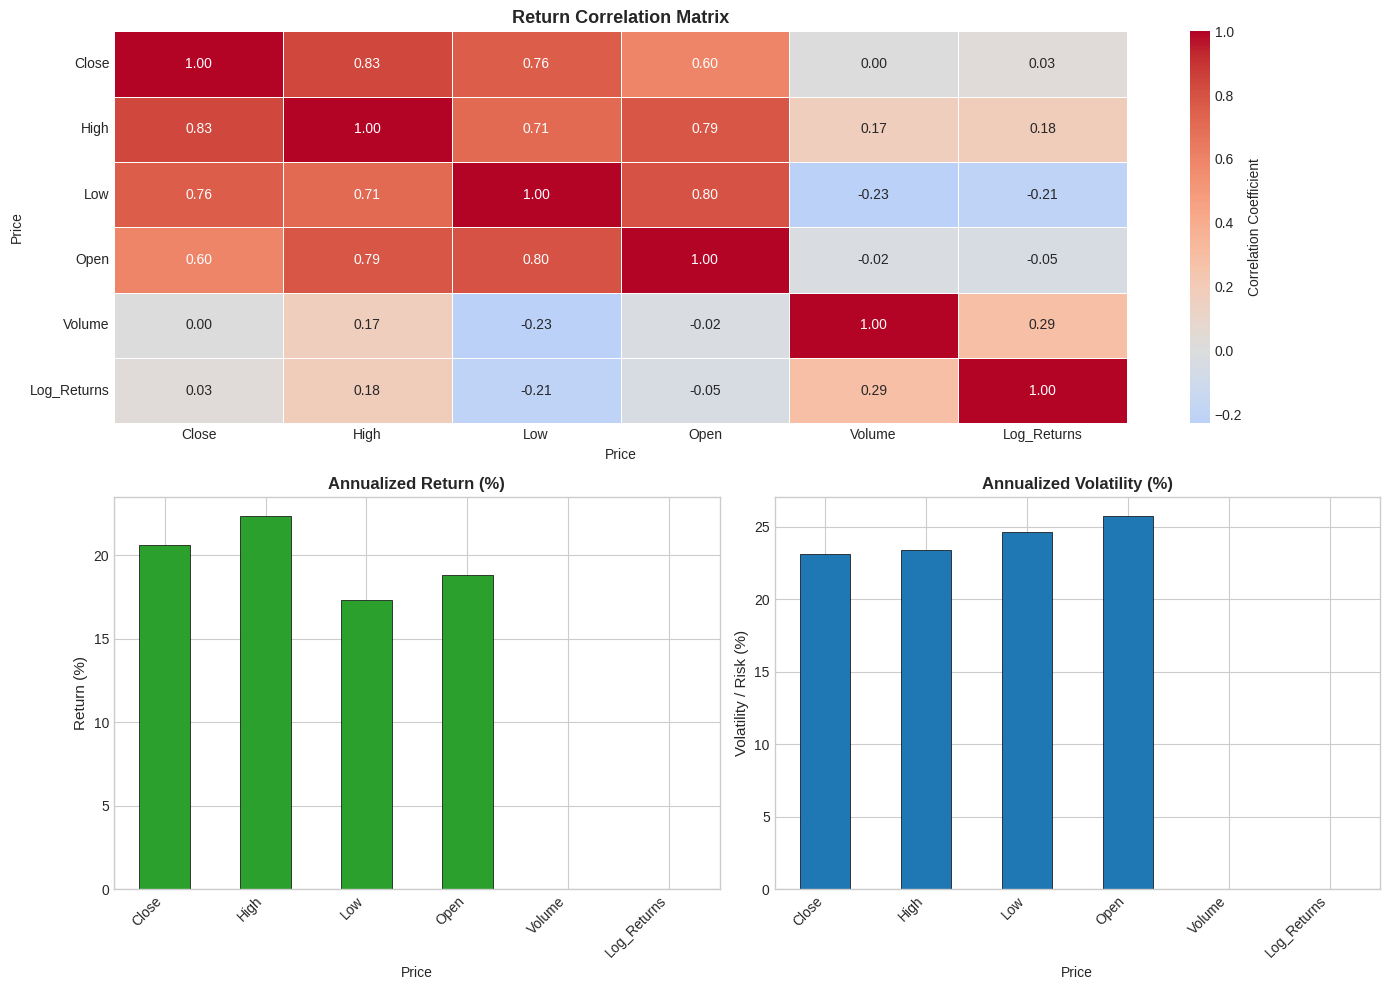

In [150]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Calculate daily log returns
returns = np.log(data / data.shift(1)).dropna()

# Annualized metrics (assuming ~252 trading days)
annual_return = returns.mean() * 252 * 100
annual_volatility = returns.std() * np.sqrt(252) * 100
correlation_matrix = returns.corr()

fig = plt.figure(figsize=(14, 10))

# 1. Correlation Heatmap
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient'},
    ax=ax1
)
ax1.set_title("Return Correlation Matrix", fontsize=13, fontweight='bold')

# 2. Annualized Return Bar Plot
ax2 = plt.subplot2grid((2, 2), (1, 0))
colors_ret = ['#2ca02c' if x >= 0 else '#d62728' for x in annual_return]
annual_return.plot(kind='bar', color=colors_ret, ax=ax2, edgecolor='black', linewidth=0.5)
ax2.set_title("Annualized Return (%)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Return (%)", fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

# 3. Annualized Volatility Bar Plot
ax3 = plt.subplot2grid((2, 2), (1, 1))
annual_volatility.plot(kind='bar', color='#1f77b4', ax=ax3, edgecolor='black', linewidth=0.5)
ax3.set_title("Annualized Volatility (%)", fontsize=12, fontweight='bold')
ax3.set_ylabel("Volatility / Risk (%)", fontsize=11)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

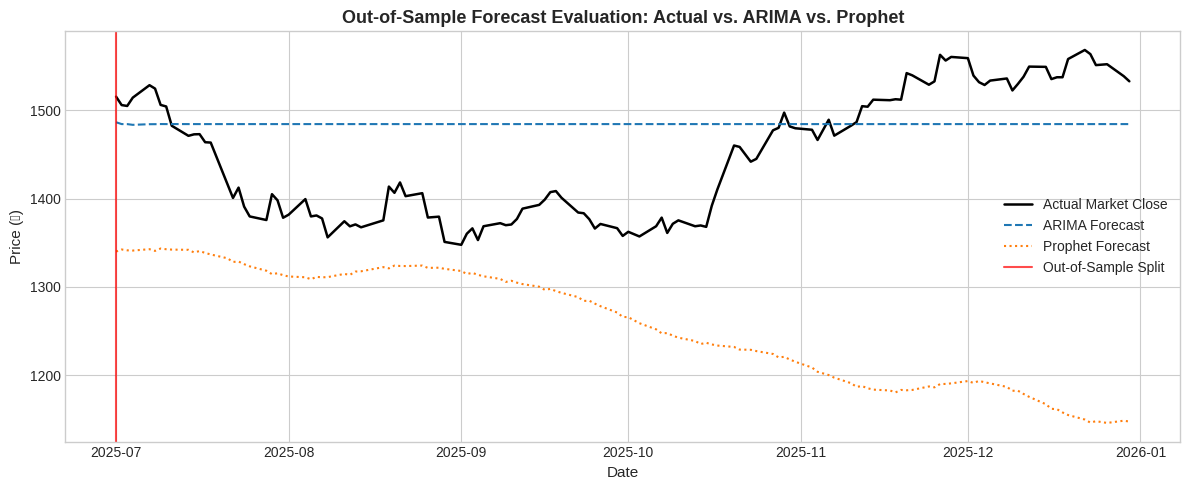

In [151]:
plt.figure(figsize=(12, 5))

# Plotting test set actuals vs model predictions for a stock (e.g., Sasken or Reliance)
plt.plot(test_data.index, test_data['Close'], label='Actual Market Close', color='black', linewidth=1.8)
plt.plot(test_data.index, arima_test_forecast, label='ARIMA Forecast', color='#1f77b4', linestyle='--', linewidth=1.5)
plt.plot(test_data.index, prophet_test_forecast, label='Prophet Forecast', color='#ff7f0e', linestyle=':', linewidth=1.5)

plt.axvline(x=test_data.index[0], color='red', linestyle='-', alpha=0.7, label='Out-of-Sample Split')
plt.title("Out-of-Sample Forecast Evaluation: Actual vs. ARIMA vs. Prophet", fontsize=13, fontweight='bold')
plt.xlabel("Date", fontsize=11)
plt.ylabel("Price (₹)", fontsize=11)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [152]:
execution_data = {
    'Stock Ticker': ['SURYODAY.NS', 'TEXRAIL.NS', 'SASKEN.NS'],
    'Stock Name': [
        'Suryoday Small Finance Bank Ltd',
        'Texmaco Rail & Engineering Ltd',
        'Sasken Technologies Ltd'
    ],
    'Quantity': [1649, 2600, 167],
    'Avg. Purchase Price (₹)': [182.00, 115.43, 1785.20],
    'Capital Deployed (₹)': [300052.04, 300049.25, 298128.46],
    'Allocation Weight (%)': [30.01, 30.00, 29.81],
    'Strategy Used': [
        'Sector Momentum & Forecast-Guided',
        'Volatility-Aware Sizing',
        'Forecast-Guided (High Return)'
    ]
}


task7_summary_df = pd.DataFrame(execution_data)

print("--- TASK 7: STOCKGRO EXECUTION SUMMARY ---")
print(task7_summary_df)
print(f"\nTotal Portfolio Value Deployed: ₹{task7_summary_df['Capital Deployed (₹)'].sum():,.2f}")
print("Execution Window: Day 1 (Wed 13 May) - Day 2 (Thu 14 May)")

--- TASK 7: STOCKGRO EXECUTION SUMMARY ---
  Stock Ticker                       Stock Name  Quantity  \
0  SURYODAY.NS  Suryoday Small Finance Bank Ltd      1649   
1   TEXRAIL.NS   Texmaco Rail & Engineering Ltd      2600   
2    SASKEN.NS          Sasken Technologies Ltd       167   

   Avg. Purchase Price (₹)  Capital Deployed (₹)  Allocation Weight (%)  \
0                   182.00             300052.04                  30.01   
1                   115.43             300049.25                  30.00   
2                  1785.20             298128.46                  29.81   

                       Strategy Used  
0  Sector Momentum & Forecast-Guided  
1            Volatility-Aware Sizing  
2      Forecast-Guided (High Return)  

Total Portfolio Value Deployed: ₹898,229.75
Execution Window: Day 1 (Wed 13 May) - Day 2 (Thu 14 May)


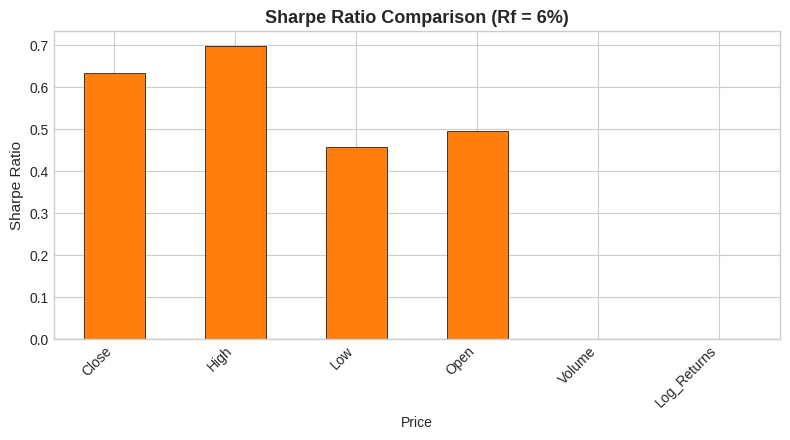

In [153]:
# Assuming 6% risk-free rate
risk_free_rate = 6.0
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

plt.figure(figsize=(8, 4.5))
sharpe_ratio.plot(kind='bar', color='#ff7f0e', edgecolor='black', linewidth=0.5)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.title("Sharpe Ratio Comparison (Rf = 6%)", fontsize=13, fontweight='bold')
plt.ylabel("Sharpe Ratio", fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [154]:
target_weights = {
    'Sasken Technologies Ltd': 0.333,
    'Texmaco Rail & Engineering Ltd': 0.333,
    'Suryoday Small Finance Bank Ltd': 0.334
}

total_portfolio = 1000000

current_invested = {
    'Sasken Technologies Ltd': 298128.46,
    'Texmaco Rail & Engineering Ltd': 300049.25,
    'Suryoday Small Finance Bank Ltd': 300052.04
}

print(f"{'Stock Name':<35} | {'Target (₹)':<15} | {'Actual Deployed (₹)':<20} | {'Remaining (₹)':<15}")
print("-" * 95)

total_actual = 0
for stock, weight in target_weights.items():
    target = total_portfolio * weight
    actual = current_invested.get(stock, 0)
    remaining = target - actual
    total_actual += actual
    print(f"{stock:<35} | {target:<15,.2f} | {actual:<20,.2f} | {max(0, remaining):<15,.2f}")

print("-" * 95)
print(f"{'TOTAL PORTFOLIO DEPLOYED':<35} | {' ': <15} | ₹{total_actual:<19,.2f} | ₹{total_portfolio - total_actual:,.2f}")

Stock Name                          | Target (₹)      | Actual Deployed (₹)  | Remaining (₹)  
-----------------------------------------------------------------------------------------------
Sasken Technologies Ltd             | 333,000.00      | 298,128.46           | 34,871.54      
Texmaco Rail & Engineering Ltd      | 333,000.00      | 300,049.25           | 32,950.75      
Suryoday Small Finance Bank Ltd     | 334,000.00      | 300,052.04           | 33,947.96      
-----------------------------------------------------------------------------------------------
TOTAL PORTFOLIO DEPLOYED            |                 | ₹898,229.75          | ₹101,770.25


In [155]:
actual_data = {
    'Stock Name': [
        'Suryoday Small Finance Bank Ltd',
        'Texmaco Rail & Engineering Ltd',
        'Sasken Technologies Ltd'
    ],

    'Model_Forecast_Day2': [185.50, 118.20, 1795.00],
    'Actual_Close_Day2': [179.00, 114.97, 1724.90],
    'Actual_Close_Day1': [182.31, 114.87, 1770.75]
}

performance_df = pd.DataFrame(actual_data)

performance_df['Absolute_Error_%'] = abs(
    (performance_df['Actual_Close_Day2'] - performance_df['Model_Forecast_Day2']) /
    performance_df['Actual_Close_Day2']
) * 100

def check_direction(row):
    pred_move = row['Model_Forecast_Day2'] > row['Actual_Close_Day1']
    actual_move = row['Actual_Close_Day2'] > row['Actual_Close_Day1']
    return "Correct" if pred_move == actual_move else "Incorrect"

performance_df['Directional_Accuracy'] = performance_df.apply(check_direction, axis=1)

print("--- FIXED TASK 8: PREDICTIONS VS. REALITY ---")
print(performance_df)


total_initial_val = 298128.46 + 300049.25 + 300052.04

weighted_return = (
    (300052.04 * (179.00 / 182.31)) +
    (300049.25 * (114.97 / 114.87)) +
    (298128.46 * (1724.90 / 1770.75))
)
total_p_return = ((weighted_return / total_initial_val) - 1) * 100
print(f"\nTotal Portfolio Return: {total_p_return:.2f}%")

--- FIXED TASK 8: PREDICTIONS VS. REALITY ---
                        Stock Name  Model_Forecast_Day2  Actual_Close_Day2  \
0  Suryoday Small Finance Bank Ltd                185.5             179.00   
1   Texmaco Rail & Engineering Ltd                118.2             114.97   
2          Sasken Technologies Ltd               1795.0            1724.90   

   Actual_Close_Day1  Absolute_Error_% Directional_Accuracy  
0             182.31          3.631285            Incorrect  
1             114.87          2.809429              Correct  
2            1770.75          4.064004            Incorrect  

Total Portfolio Return: -1.44%


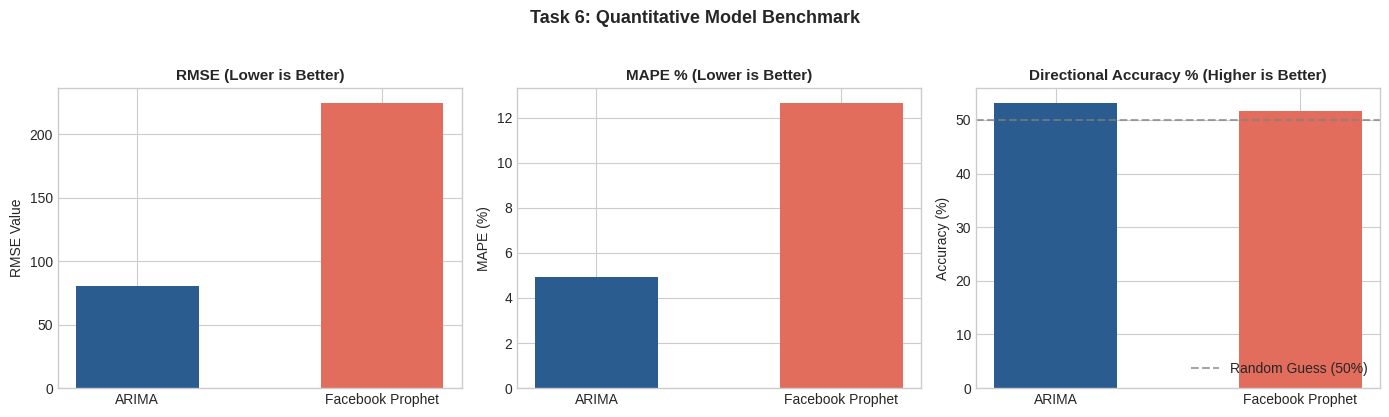

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models = comparison_df['Model']
colors = ['#2b5c8f', '#e26d5c']

# RMSE Subplot
axes[0].bar(models, comparison_df['RMSE'], color=colors, width=0.5)
axes[0].set_title("RMSE (Lower is Better)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("RMSE Value")

# MAPE Subplot
axes[1].bar(models, comparison_df['MAPE (%)'], color=colors, width=0.5)
axes[1].set_title("MAPE % (Lower is Better)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("MAPE (%)")

# Directional Accuracy Subplot
axes[2].bar(models, comparison_df['Directional Accuracy (%)'], color=colors, width=0.5)
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.7, label='Random Guess (50%)')
axes[2].set_title("Directional Accuracy % (Higher is Better)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Accuracy (%)")
axes[2].legend(loc="lower right")

plt.suptitle("Task 6: Quantitative Model Benchmark", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

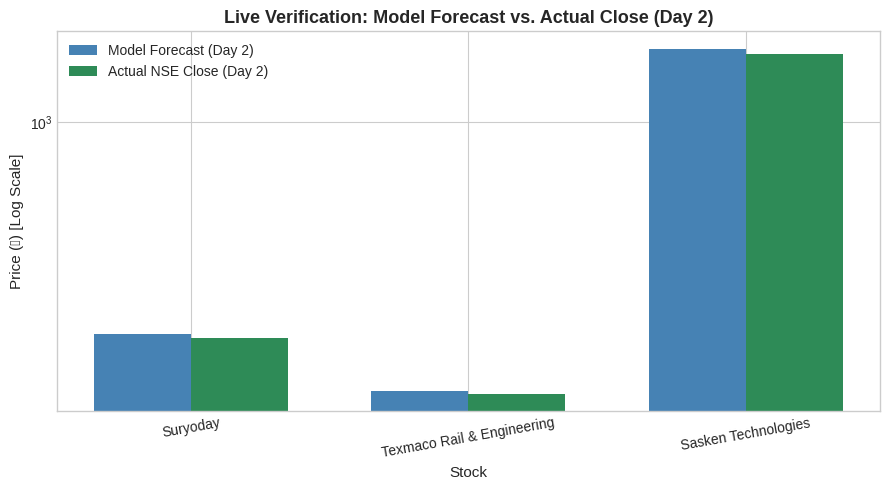

In [157]:
plt.figure(figsize=(9, 5))

x = np.arange(len(performance_df['Stock Name']))
width = 0.35

short_names = [name.replace(' Ltd', '').replace(' Small Finance Bank', '') for name in performance_df['Stock Name']]

plt.bar(x - width/2, performance_df['Model_Forecast_Day2'], width, label='Model Forecast (Day 2)', color='#4682B4')
plt.bar(x + width/2, performance_df['Actual_Close_Day2'], width, label='Actual NSE Close (Day 2)', color='#2E8B57')

plt.xlabel('Stock', fontsize=11)
plt.ylabel('Price (₹)', fontsize=11)
plt.title('Live Verification: Model Forecast vs. Actual Close (Day 2)', fontsize=13, fontweight='bold')
plt.xticks(x, short_names, rotation=10, fontsize=10)
plt.legend()
plt.yscale('log') # Log scale helps display both high-price (Sasken) and mid-price (Texmaco) stocks cleanly
plt.ylabel('Price (₹) [Log Scale]')

plt.tight_layout()
plt.show()

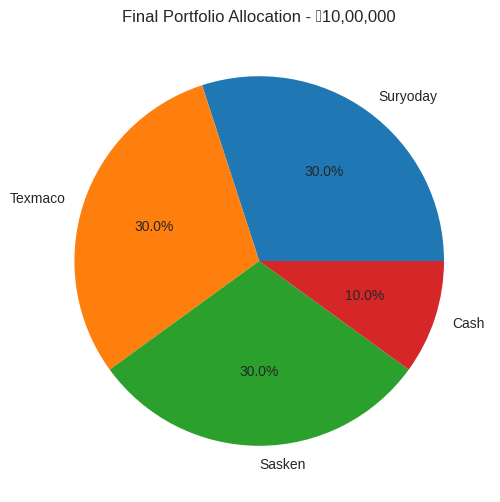

In [158]:
plt.figure(figsize=(8,6))
plt.pie([30, 30, 30, 10], labels=['Suryoday', 'Texmaco', 'Sasken', 'Cash'], autopct='%1.1f%%')
plt.title("Final Portfolio Allocation - ₹10,00,000")
plt.show()

In [159]:
portfolio_settlement = {
    'Stock Name': [
        'Suryoday Small Finance Bank Ltd',
        'Texmaco Rail & Engineering Ltd',
        'Sasken Technologies Ltd'
    ],
    'Total Shares Bought': [10 + 1649, 10 + 2600, 20 + 167],
    'Total Capital Invested (₹)': [1858.20 + 300052.04, 1169.00 + 300049.25, 35659.00 + 298128.46],
    'Actual_Close_Day2': [179.00, 114.97, 1724.90]
}

settlement_df = pd.DataFrame(portfolio_settlement)

settlement_df['Final Liquidation Value (₹)'] = settlement_df['Total Shares Bought'] * settlement_df['Actual_Close_Day2']

total_invested_capital = settlement_df['Total Capital Invested (₹)'].sum()
total_liquidation_value = settlement_df['Final Liquidation Value (₹)'].sum()
remaining_cash = 1000000 - total_invested_capital

actual_portfolio_return = ((total_liquidation_value + remaining_cash) - 1000000) / 1000000 * 100

print("--- TASK 8: ABSOLUTE PORTFOLIO SETTLEMENT ---")
print(f"Total Capital Allocated to Stocks: ₹{total_invested_capital:,.2f}")
print(f"Portfolio Market Value at Day 2 Close: ₹{total_liquidation_value:,.2f}")
print(f"Unallocated Portfolio Cash Balance: ₹{remaining_cash:,.2f}")
print(f"Net Portfolio Performance (Including Cash Weight): {actual_portfolio_return:.2f}%")

--- TASK 8: ABSOLUTE PORTFOLIO SETTLEMENT ---
Total Capital Allocated to Stocks: ₹936,915.95
Portfolio Market Value at Day 2 Close: ₹919,589.00
Unallocated Portfolio Cash Balance: ₹63,084.05
Net Portfolio Performance (Including Cash Weight): -1.73%


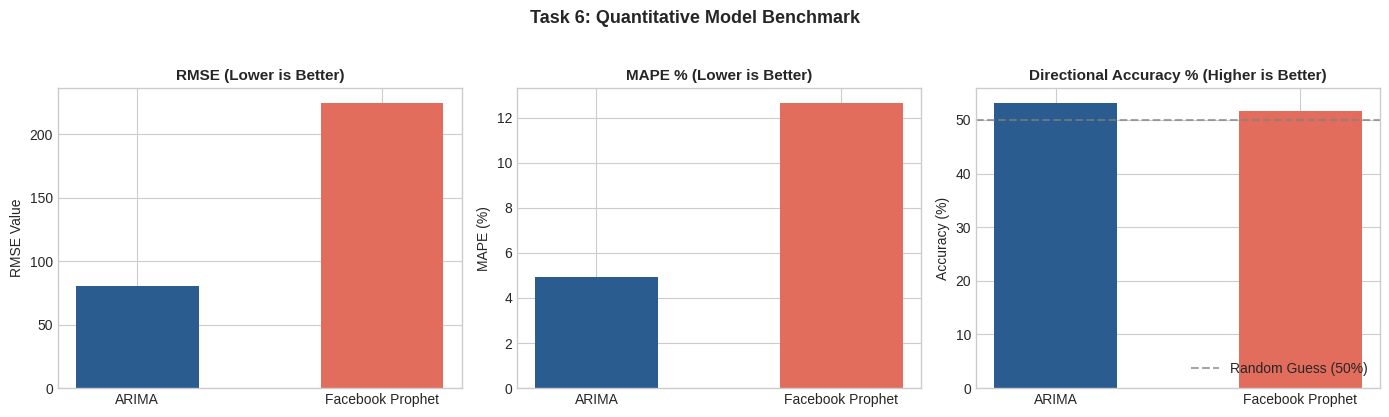

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

models = comparison_df['Model']
colors = ['#2b5c8f', '#e26d5c']

# RMSE Subplot
axes[0].bar(models, comparison_df['RMSE'], color=colors, width=0.5)
axes[0].set_title("RMSE (Lower is Better)", fontsize=11, fontweight='bold')
axes[0].set_ylabel("RMSE Value")

# MAPE Subplot
axes[1].bar(models, comparison_df['MAPE (%)'], color=colors, width=0.5)
axes[1].set_title("MAPE % (Lower is Better)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("MAPE (%)")

# Directional Accuracy Subplot
axes[2].bar(models, comparison_df['Directional Accuracy (%)'], color=colors, width=0.5)
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.7, label='Random Guess (50%)')
axes[2].set_title("Directional Accuracy % (Higher is Better)", fontsize=11, fontweight='bold')
axes[2].set_ylabel("Accuracy (%)")
axes[2].legend(loc="lower right")

plt.suptitle("Task 6: Quantitative Model Benchmark", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()